## 1. Setup and Imports

In [1]:
import jax
import jax.numpy as jnp
import jax.random as jar
import matplotlib.pyplot as plt
import seaborn as sns
import time
from typing import Dict, List, Callable, Any, Optional
from dataclasses import dataclass, field

# MalthusJAX imports
from malthusjax.core.genome.real_genome import RealGenomeConfig
from malthusjax.core.fitness.bbob_evaluator import BBOBEvaluator, BBOBConfig
from malthusjax.engine.genetic_fastengine import GeneticEngine, GeneticEngineParams
from malthusjax.engine.base import AbstractEngineParams
from malthusjax.operators.selection.elite_pool import ElitePoolSelection
from malthusjax.operators.crossover.real import UniformCrossover
from malthusjax.operators.mutation.real import GaussianMutation
from malthusjax.operators.crossover.real import BinomialCrossover

# Evosax imports
from evosax.algorithms import SimpleGA, MR15_GA, DifferentialEvolution
from evosax.problems import BBOBProblem, bbob_fns

# Styling
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

print(f"JAX version: {jax.__version__}")
print(f"JAX backend: {jax.default_backend()}")
print(f"Running on: {jax.devices()[0].device_kind}")
print("✅ All imports successful")

JAX version: 0.8.0
JAX backend: cpu
Running on: cpu
✅ All imports successful


In [2]:
# Random seed
SEED = 42
key = jar.PRNGKey(SEED)

## 2. Visualize BBOB Functions

Let's visualize a subset of BBOB functions to understand the landscape characteristics.

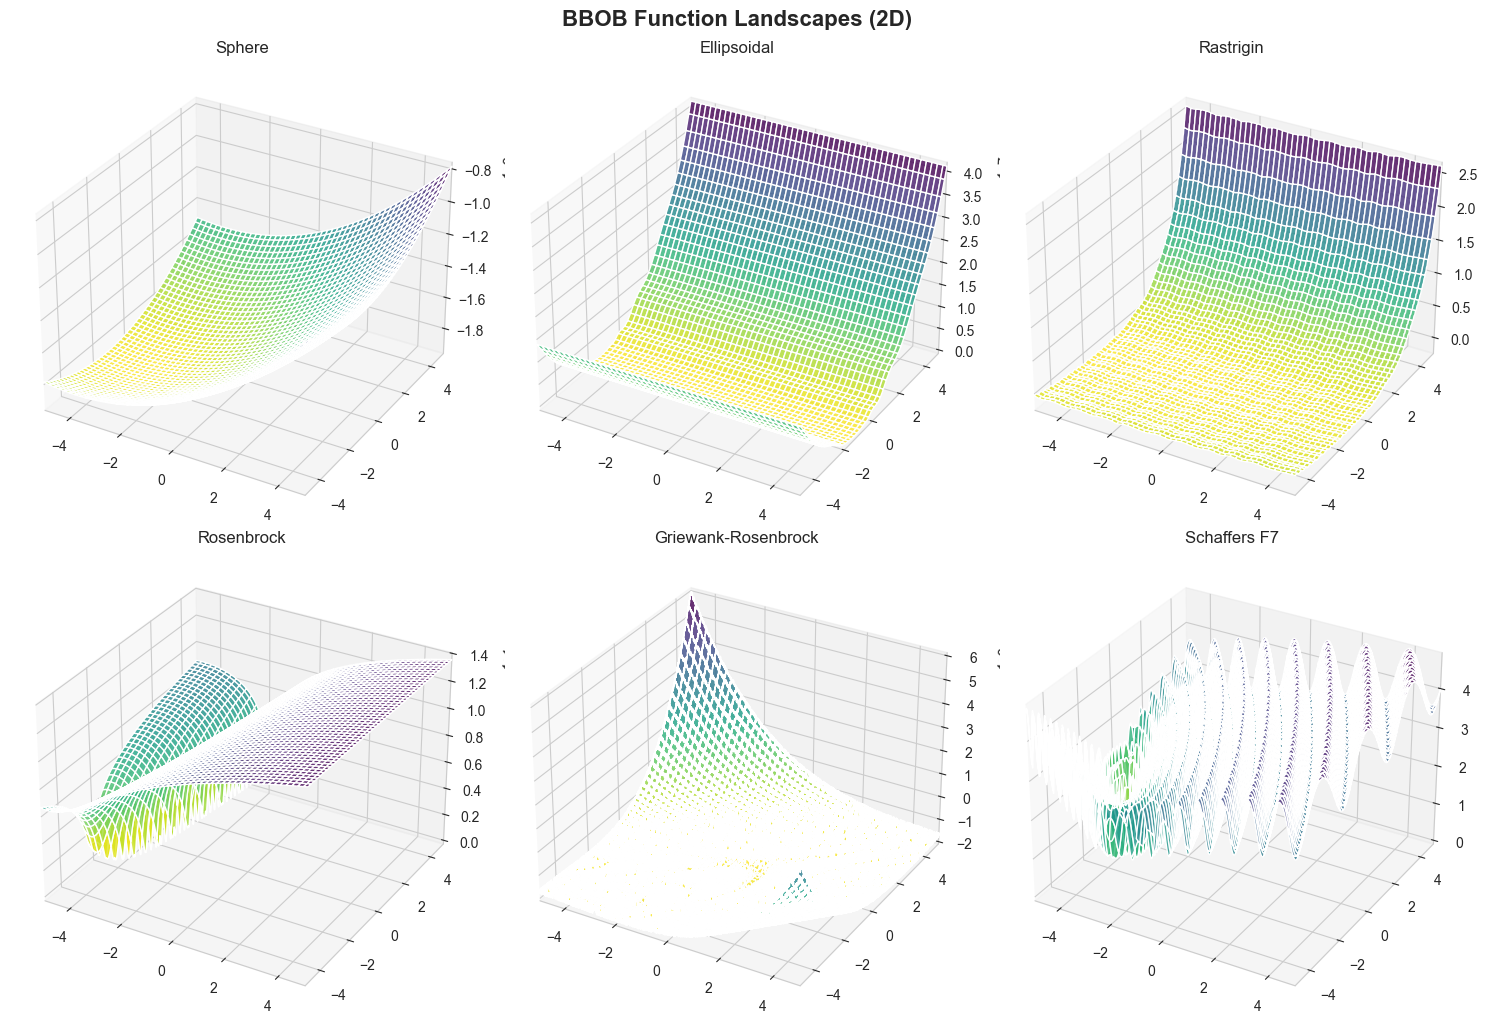

In [3]:
# Select representative functions
viz_functions = [
    "sphere",
    "ellipsoidal", 
    "rastrigin",
    "rosenbrock",
    "griewank_rosenbrock",
    "schaffers_f7"
]

num_dims = 2
problems_2d = {
    fn: BBOBProblem(fn, num_dims=num_dims, seed=SEED)
    for fn in viz_functions
}

# Create visualization grid
fig, axes = plt.subplots(2, 3, figsize=(15, 10), subplot_kw={"projection": "3d"})
axes = axes.flatten()

logscale_fns = ["rosenbrock", "schaffers_f7"]

for i, (fn_name, problem) in enumerate(problems_2d.items()):
    key, subkey = jar.split(key)
    problem.visualize_3d(
        subkey, 
        ax=axes[i], 
        logscale=fn_name in logscale_fns
    )
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")
    axes[i].set_zlabel("")

plt.tight_layout()
plt.suptitle("BBOB Function Landscapes (2D)", fontsize=16, fontweight='bold', y=1.02)
plt.show()

## 3. Single-Function Benchmark Configuration

In [4]:
# ============================================================================
# SINGLE BENCHMARK CONFIGURATION
# ============================================================================

# Problem Configuration
PROBLEM_NAME = "rastrigin"         # BBOB function name
DIMENSIONS = 20                    # Problem dimensionality
BOUNDS = (-5.0, 5.0)               # Search space bounds
FIXED_PROBLEM_SEED = 0             # Fixed landscape seed

# Evolution Parameters
POPULATION_SIZE = 100              # Population size
NUM_GENERATIONS = 300              # Number of generations
CROSSOVER_RATE = 0.9               # Crossover probability
ELITE_RATIO = 0.2                  # Proportion of elites
MUTATION_RATE = 0.3                # Mutation probability
MUTATION_STRENGTH = 0.1            # Gaussian mutation strength

# Display
VERBOSE = False                    # Print progress during runs

# Derived
ELITE_POOL_SIZE = int(POPULATION_SIZE * ELITE_RATIO)

print("📋 Single Benchmark Configuration")
print("=" * 70)
print(f"Problem:          {PROBLEM_NAME} ({DIMENSIONS}D)")
print(f"Search Space:     {BOUNDS}")
print(f"Population Size:  {POPULATION_SIZE:,}")
print(f"Generations:      {NUM_GENERATIONS}")
print(f"Problem Seed:     {FIXED_PROBLEM_SEED}")
print("=" * 70)

📋 Single Benchmark Configuration
Problem:          rastrigin (20D)
Search Space:     (-5.0, 5.0)
Population Size:  100
Generations:      300
Problem Seed:     0


## 4. Setup Engines

In [6]:
# Shared genome configuration
genome_config = RealGenomeConfig(shape=(DIMENSIONS,), bounds=BOUNDS)

# MalthusJAX evaluator (maximization by flipping sign)
mjx_eval_config = BBOBConfig(
    fn_name=PROBLEM_NAME,
    num_dims=DIMENSIONS,
    seed=FIXED_PROBLEM_SEED,
    maximize=True  # Flips sign for minimization
)
mjx_evaluator = BBOBEvaluator.create(mjx_eval_config)

# Evosax problem (minimization)
evosax_problem = BBOBProblem(PROBLEM_NAME, num_dims=DIMENSIONS, seed=FIXED_PROBLEM_SEED)

print(f"✅ Problem setup: {PROBLEM_NAME} ({DIMENSIONS}D)")

✅ Problem setup: rastrigin (20D)


In [8]:
# --- MalthusJAX: Standard Genetic Engine ---
selection_std = ElitePoolSelection(num_selections=POPULATION_SIZE, elite_k=ELITE_POOL_SIZE, input_length=POPULATION_SIZE)
crossover_std = UniformCrossover(num_offspring=2, crossover_rate=CROSSOVER_RATE)
mutation_std = GaussianMutation(num_offspring=1, mutation_rate=MUTATION_RATE, mutation_strength=MUTATION_STRENGTH)

std_engine = GeneticEngine(
    evaluator=mjx_evaluator, selection=selection_std, crossover=crossover_std, mutation=mutation_std,
    genome_config=genome_config, engine_params=GeneticEngineParams(pop_size=POPULATION_SIZE, num_generations=NUM_GENERATIONS, elitism=0)
)

# --- Evosax: SimpleGA ---
init_solution = evosax_problem.sample(jar.PRNGKey(42))
evosax_simple_ga = SimpleGA(population_size=POPULATION_SIZE, solution=init_solution)

# --- Evosax: MR15_GA ---
evosax_mr15 = MR15_GA(population_size=POPULATION_SIZE, solution=evosax_problem.sample(jar.PRNGKey(43)))

# --- Evosax: DifferentialEvolution ---
evosax_de = DifferentialEvolution(population_size=POPULATION_SIZE, solution=evosax_problem.sample(jar.PRNGKey(44)))


## 5. Helper Functions

In [9]:
def run_malthusjax_engine(engine, name, seed=42, warm=False):
    """Run a MalthusJAX engine and collect history.
    
    Args:
        engine: The MalthusJAX engine instance
        name: Engine name for display
        seed: Random seed
        warm: If True, runs a warmup iteration first to JIT compile
    """
    run_type = "warm" if warm else "cold"
    print(f"Running {name} ({run_type})...", end=" ")
    
    key = jar.PRNGKey(seed)
    state = engine.init_state(key)
    
    # Warmup run if requested
    if warm:
        _, _, _ = engine.run(state, time_it=False, compile=True, verbose=False)
        # Re-initialize for the actual timed run
        key = jar.PRNGKey(seed)
        state = engine.init_state(key)
    
    start = time.time()
    final_state, history, _ = engine.run(state, time_it=False, compile=True, verbose=VERBOSE)
    elapsed = time.time() - start
    
    # Convert to minimization
    best_fitness = -final_state.best_fitness if mjx_eval_config.maximize else final_state.best_fitness
    mean_fitness = -history.mean_fitness if mjx_eval_config.maximize else history.mean_fitness
    best_history = -history.best_fitness if mjx_eval_config.maximize else history.best_fitness
    
    print(f"✓ ({elapsed:.2f}s, final={best_fitness:.6f})")
    
    return {
        'name': f"{name} ({run_type})", 
        'base_name': name,
        'run_type': run_type,
        'best_fitness': best_fitness, 
        'best_history': best_history,
        'mean_history': mean_fitness, 
        'generations': jnp.arange(len(best_history)), 
        'runtime': elapsed
    }

def run_evosax_engine(strategy, params, problem, name, seed=42, warm=False):
    """Run an Evosax engine and collect history.
    
    Args:
        strategy: The Evosax strategy instance
        params: Strategy parameters
        problem: The BBOB problem
        name: Engine name for display
        seed: Random seed
        warm: If True, runs a warmup iteration first to JIT compile
    """
    run_type = "warm" if warm else "cold"
    print(f"Running {name} ({run_type})...", end=" ")
    
    rng = jar.PRNGKey(seed)
    rng_init, rng_pop, rng_run = jax.random.split(rng, 3)
    
    initial_pop = jax.random.uniform(rng_pop, (POPULATION_SIZE, DIMENSIONS), minval=BOUNDS[0], maxval=BOUNDS[1])
    initial_fitness = jnp.full((POPULATION_SIZE,), jnp.inf)
    state = strategy.init(rng_init, initial_pop, initial_fitness, params)
    prob_state = problem.init(jar.PRNGKey(FIXED_PROBLEM_SEED))
    
    def step_fn(carry, _):
        state, prob_state, rng = carry
        rng_ask, rng_eval, rng_tell, rng_next = jax.random.split(rng, 4)
        x, state = strategy.ask(rng_ask, state, params)
        x = jnp.clip(x, BOUNDS[0], BOUNDS[1])  # Clip to bounds (automatic in MalthusJAX)
        fitness, prob_state, _ = problem.eval(rng_eval, x, prob_state)
        state, metrics = strategy.tell(rng_tell, x, fitness, state, params)
        return (state, prob_state, rng_next), (fitness.min(), fitness.mean())
    
    carry_init = (state, prob_state, rng_run)
    
    # Warmup run if requested
    if warm:
        _, _ = jax.lax.scan(step_fn, carry_init, xs=None, length=NUM_GENERATIONS)
        jax.block_until_ready(_)
        # Re-initialize for the actual timed run
        rng = jar.PRNGKey(seed)
        rng_init, rng_pop, rng_run = jax.random.split(rng, 3)
        initial_pop = jax.random.uniform(rng_pop, (POPULATION_SIZE, DIMENSIONS), minval=BOUNDS[0], maxval=BOUNDS[1])
        state = strategy.init(rng_init, initial_pop, initial_fitness, params)
        prob_state = problem.init(jar.PRNGKey(FIXED_PROBLEM_SEED))
        carry_init = (state, prob_state, rng_run)
    
    start = time.time()
    _, history = jax.lax.scan(step_fn, carry_init, xs=None, length=NUM_GENERATIONS)
    history = jax.block_until_ready(history)
    elapsed = time.time() - start
    
    best_history, mean_history = history
    
    print(f"✓ ({elapsed:.2f}s, final={best_history[-1]:.6f})")
    
    return {
        'name': f"{name} ({run_type})",
        'base_name': name,
        'run_type': run_type,
        'best_fitness': float(best_history[-1]), 
        'best_history': best_history,
        'mean_history': mean_history, 
        'generations': jnp.arange(len(best_history)), 
        'runtime': elapsed
    }

print("✅ Helper functions defined (with cold/warm run support)")

✅ Helper functions defined (with cold/warm run support)


## 6. Run Single-Function Benchmark

In [11]:
print(f"\n🚀 Running single-function benchmark: {PROBLEM_NAME}")
print("Each engine will run twice: COLD (with JIT compilation) and WARM (pre-compiled)\n")

results = []

# Define engine configurations
malthusjax_configs = [
    (std_engine, "MalthusJAX - GeneticEngine"),
]

evosax_configs = [
    (evosax_simple_ga, evosax_simple_ga.default_params, "Evosax - SimpleGA"),
    (evosax_mr15, evosax_mr15.default_params, "Evosax - MR15_GA"),
    (evosax_de, evosax_de.default_params, "Evosax - DiffEvolution")
]

# Run MalthusJAX engines (cold then warm)
print("=" * 70)
print("MalthusJAX Engines")
print("=" * 70)
for engine, name in malthusjax_configs:
    results.append(run_malthusjax_engine(engine, name, warm=False))  # Cold run
    results.append(run_malthusjax_engine(engine, name, warm=True))   # Warm run

# Run Evosax engines (cold then warm)
print("\n" + "=" * 70)
print("Evosax Engines")
print("=" * 70)
for strategy, params, name in evosax_configs:
    results.append(run_evosax_engine(strategy, params, evosax_problem, name, warm=False))  # Cold run
    results.append(run_evosax_engine(strategy, params, evosax_problem, name, warm=True))   # Warm run

print(f"\n✅ Benchmark complete! Tested {len(results)//2} engines × 2 runs = {len(results)} total runs")


🚀 Running single-function benchmark: rastrigin
Each engine will run twice: COLD (with JIT compilation) and WARM (pre-compiled)

MalthusJAX Engines
Running MalthusJAX - GeneticEngine (cold)... ✓ (5.17s, final=116.618439)
Running MalthusJAX - GeneticEngine (warm)... ✓ (0.04s, final=116.618439)

Evosax Engines
Running Evosax - SimpleGA (cold)... ✓ (0.40s, final=315.238281)
Running Evosax - SimpleGA (warm)... ✓ (0.07s, final=315.238281)
Running Evosax - MR15_GA (cold)... ✓ (0.48s, final=101.750992)
Running Evosax - MR15_GA (warm)... ✓ (0.03s, final=101.750992)
Running Evosax - DiffEvolution (cold)... ✓ (1.57s, final=149.694550)
Running Evosax - DiffEvolution (warm)... ✓ (0.06s, final=149.694550)

✅ Benchmark complete! Tested 4 engines × 2 runs = 8 total runs


## 7. Results Summary

In [12]:
print("\n" + "="*95)
print(f"RESULTS: {PROBLEM_NAME.upper()} ({DIMENSIONS}D) - JIT Overhead Analysis")
print("="*95)
print(f"{'Engine':<35} {'Type':>8} {'Best Fitness':>15} {'Runtime (s)':>12} {'Overhead':>12}")
print("-"*95)

# Group results by base engine
from collections import defaultdict
grouped_results = defaultdict(list)
for r in results:
    grouped_results[r['base_name']].append(r)

# Display grouped by engine
for base_name in sorted(grouped_results.keys()):
    runs = grouped_results[base_name]
    # Sort to ensure cold is first, warm second
    runs = sorted(runs, key=lambda x: x['run_type'], reverse=True)  # 'warm' > 'cold' alphabetically
    
    cold_run = runs[1] if runs[1]['run_type'] == 'cold' else runs[0]
    warm_run = runs[0] if runs[0]['run_type'] == 'warm' else runs[1]
    
    overhead = cold_run['runtime'] - warm_run['runtime']
    overhead_pct = (overhead / cold_run['runtime']) * 100 if cold_run['runtime'] > 0 else 0
    
    print(f"{base_name:<35} {'COLD':>8} {cold_run['best_fitness']:>15.6f} {cold_run['runtime']:>12.2f}")
    print(f"{'':<35} {'WARM':>8} {warm_run['best_fitness']:>15.6f} {warm_run['runtime']:>12.2f} {f'+{overhead:.2f}s ({overhead_pct:.1f}%)':>12}")
    print()

print("="*95)

# Compute overall statistics
cold_results = [r for r in results if r['run_type'] == 'cold']
warm_results = [r for r in results if r['run_type'] == 'warm']

avg_cold = sum(r['runtime'] for r in cold_results) / len(cold_results)
avg_warm = sum(r['runtime'] for r in warm_results) / len(warm_results)
avg_overhead = avg_cold - avg_warm
avg_overhead_pct = (avg_overhead / avg_cold) * 100

print(f"\n📊 Average JIT Compilation Overhead:")
print(f"   Cold Run:  {avg_cold:.2f}s")
print(f"   Warm Run:  {avg_warm:.2f}s")
print(f"   Overhead:  {avg_overhead:.2f}s ({avg_overhead_pct:.1f}%)")

best_warm = min(warm_results, key=lambda x: x['best_fitness'])
fastest_warm = min(warm_results, key=lambda x: x['runtime'])

print(f"\n🏆 Best Fitness (warm):  {best_warm['base_name']} ({best_warm['best_fitness']:.6f})")
print(f"⚡ Fastest (warm):       {fastest_warm['base_name']} ({fastest_warm['runtime']:.2f}s)")


RESULTS: RASTRIGIN (20D) - JIT Overhead Analysis
Engine                                  Type    Best Fitness  Runtime (s)     Overhead
-----------------------------------------------------------------------------------------------
Evosax - DiffEvolution                  COLD      149.694550         1.57
                                        WARM      149.694550         0.06 +1.51s (96.1%)

Evosax - MR15_GA                        COLD      101.750992         0.48
                                        WARM      101.750992         0.03 +0.45s (94.3%)

Evosax - SimpleGA                       COLD      315.238281         0.40
                                        WARM      315.238281         0.07 +0.32s (81.8%)

MalthusJAX - GeneticEngine              COLD      116.618439         5.17
                                        WARM      116.618439         0.04 +5.13s (99.2%)


📊 Average JIT Compilation Overhead:
   Cold Run:  1.90s
   Warm Run:  0.05s
   Overhead:  1.85s (97.3%)

🏆 Bes

## 8. Visualization

StopIteration: 

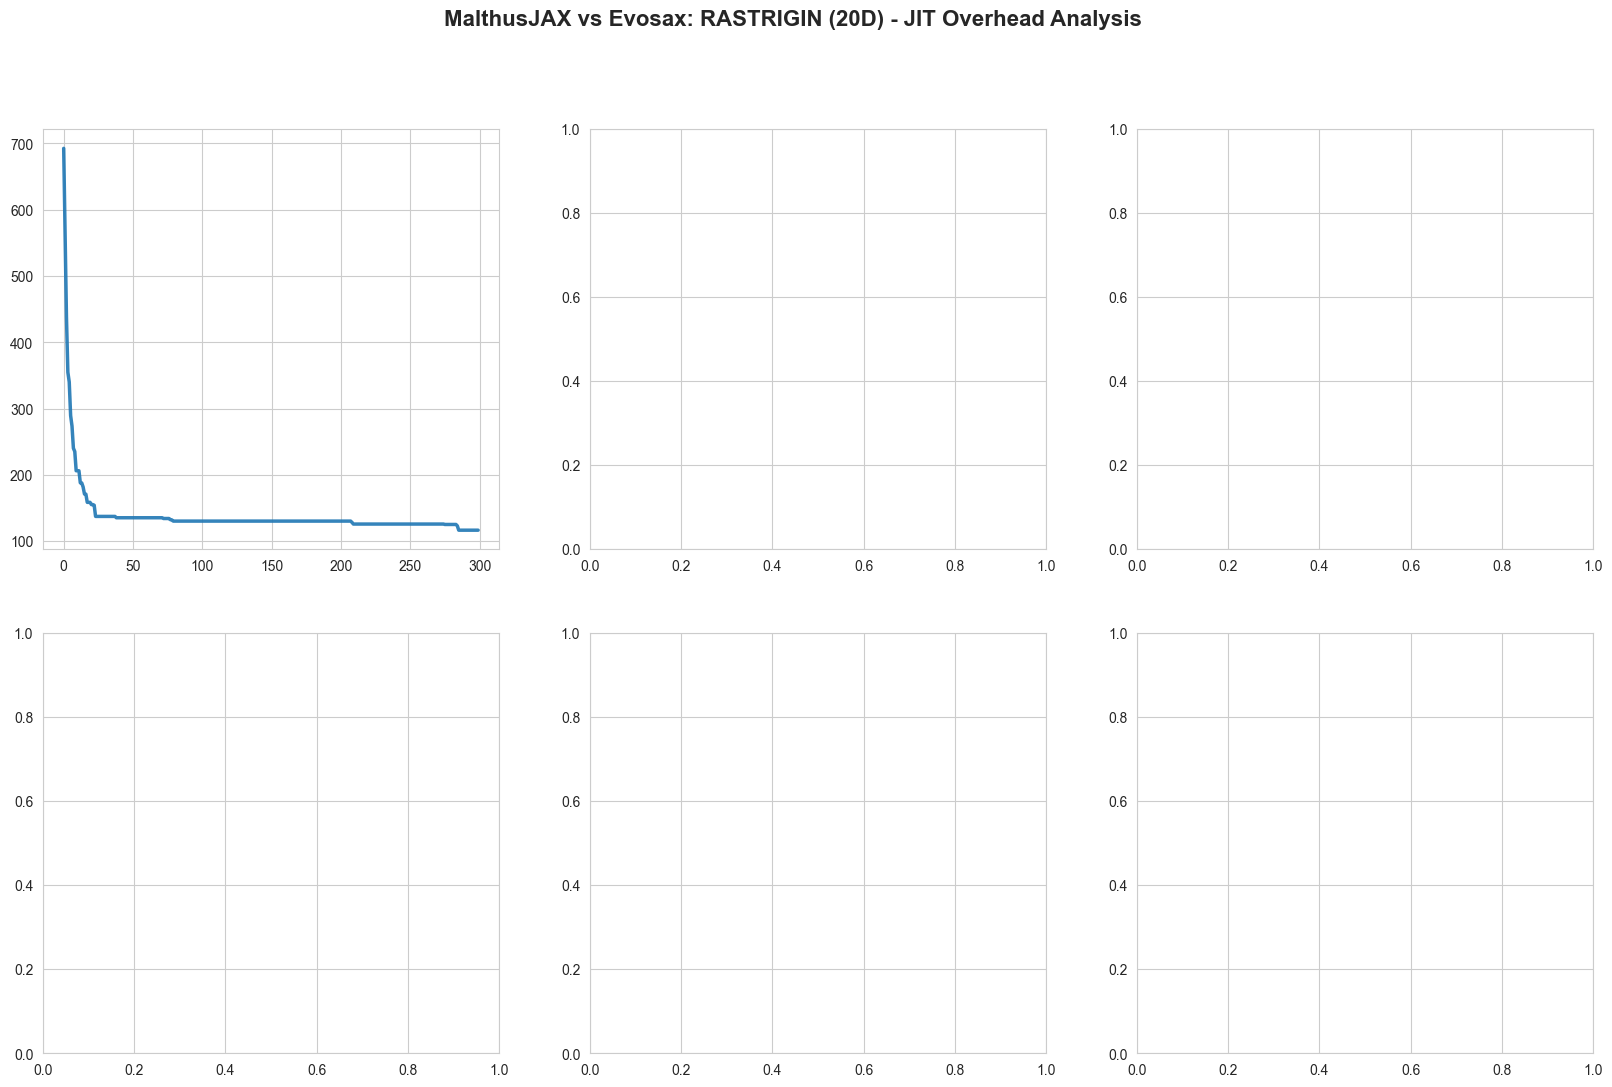

In [13]:
malthusjax_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
evosax_colors = ['#9467bd', '#8c564b', '#e377c2']

# Separate cold and warm results
cold_results = [r for r in results if r['run_type'] == 'cold']
warm_results = [r for r in results if r['run_type'] == 'warm']

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle(f'MalthusJAX vs Evosax: {PROBLEM_NAME.upper()} ({DIMENSIONS}D) - JIT Overhead Analysis', 
             fontsize=16, fontweight='bold')

# Plot 1: Best Fitness Convergence (Warm runs only)
ax1 = axes[0, 0]
for i, base_name in enumerate(["MalthusJAX - GeneticEngine", "MalthusJAX - OneFifthRule", "MalthusJAX - EMA", "MalthusJAX - DiffEvolution"]):
    r = next(r for r in warm_results if r['base_name'] == base_name)
    ax1.plot(r['generations'], r['best_history'], label=base_name.replace('MalthusJAX - ', 'MJX: '),
             color=malthusjax_colors[i], linewidth=2.5, alpha=0.9)
for i, base_name in enumerate(["Evosax - SimpleGA", "Evosax - MR15_GA", "Evosax - DiffEvolution"]):
    r = next(r for r in warm_results if r['base_name'] == base_name)
    ax1.plot(r['generations'], r['best_history'], label=base_name.replace('Evosax - ', 'EVX: '),
             color=evosax_colors[i], linewidth=2.5, linestyle='--', alpha=0.9)
ax1.set_yscale('symlog', linthresh=1e-10)
ax1.set_xlabel('Generation', fontsize=11, fontweight='bold')
ax1.set_ylabel('Best Fitness (Log)', fontsize=11, fontweight='bold')
ax1.set_title('Best Fitness Convergence (Warm Runs)', fontsize=12, fontweight='bold')
ax1.legend(fontsize=8, loc='best')
ax1.grid(True, alpha=0.3)

# Plot 2: Runtime Comparison - Cold vs Warm
ax2 = axes[0, 1]
base_names = sorted(set(r['base_name'] for r in results))
short_names = [name.split(' - ')[1] for name in base_names]
x_pos = jnp.arange(len(base_names))
width = 0.35

cold_times = [next(r['runtime'] for r in cold_results if r['base_name'] == name) for name in base_names]
warm_times = [next(r['runtime'] for r in warm_results if r['base_name'] == name) for name in base_names]

bars1 = ax2.bar(x_pos - width/2, cold_times, width, label='Cold (with JIT)', color='#e74c3c', alpha=0.8, edgecolor='black')
bars2 = ax2.bar(x_pos + width/2, warm_times, width, label='Warm (pre-compiled)', color='#2ecc71', alpha=0.8, edgecolor='black')

ax2.set_ylabel('Runtime (seconds)', fontsize=11, fontweight='bold')
ax2.set_title('Cold vs Warm Runtime Comparison', fontsize=12, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(short_names, rotation=45, ha='right', fontsize=9)
ax2.legend(fontsize=10)
ax2.grid(axis='y', alpha=0.3)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}s', ha='center', va='bottom', fontsize=8)

# Plot 3: JIT Overhead Percentage
ax3 = axes[0, 2]
overhead_pct = [(c - w) / c * 100 for c, w in zip(cold_times, warm_times)]
colors_all = malthusjax_colors + evosax_colors
bars = ax3.barh(short_names, overhead_pct, color=colors_all, alpha=0.75, edgecolor='black', linewidth=1.5)
ax3.set_xlabel('JIT Overhead (%)', fontsize=11, fontweight='bold')
ax3.set_title('Compilation Overhead', fontsize=12, fontweight='bold')
ax3.grid(axis='x', alpha=0.3)
for bar, val in zip(bars, overhead_pct):
    ax3.text(val + 1, bar.get_y() + bar.get_height()/2, f'{val:.1f}%',
             ha='left', va='center', fontsize=9, fontweight='bold')

# Plot 4: Final Performance (Warm runs)
ax4 = axes[1, 0]
finals = [r['best_fitness'] for r in warm_results]
bars = ax4.barh(short_names, finals, color=colors_all, alpha=0.75, edgecolor='black', linewidth=1.5)
ax4.set_xlabel('Final Best Fitness', fontsize=11, fontweight='bold')
ax4.set_title('Final Performance (Warm Runs)', fontsize=12, fontweight='bold')
ax4.grid(axis='x', alpha=0.3)
for bar, val in zip(bars, finals):
    ax4.text(val + abs(val)*0.02, bar.get_y() + bar.get_height()/2, f'{val:.4f}',
             ha='left', va='center', fontsize=8, fontweight='bold')
best_idx = finals.index(min(finals))
bars[best_idx].set_edgecolor('gold')
bars[best_idx].set_linewidth(3)

# Plot 5: Absolute Overhead Time
ax5 = axes[1, 1]
overhead_abs = [c - w for c, w in zip(cold_times, warm_times)]
bars = ax5.barh(short_names, overhead_abs, color='#f39c12', alpha=0.75, edgecolor='black', linewidth=1.5)
ax5.set_xlabel('Compilation Time (seconds)', fontsize=11, fontweight='bold')
ax5.set_title('Absolute JIT Overhead', fontsize=12, fontweight='bold')
ax5.grid(axis='x', alpha=0.3)
for bar, val in zip(bars, overhead_abs):
    ax5.text(val + max(overhead_abs)*0.02, bar.get_y() + bar.get_height()/2, f'{val:.2f}s',
             ha='left', va='center', fontsize=9, fontweight='bold')

# Plot 6: Speedup Factor
ax6 = axes[1, 2]
speedup = [c / w if w > 0 else 1 for c, w in zip(cold_times, warm_times)]
bars = ax6.barh(short_names, speedup, color='#3498db', alpha=0.75, edgecolor='black', linewidth=1.5)
ax6.set_xlabel('Speedup Factor (Cold / Warm)', fontsize=11, fontweight='bold')
ax6.set_title('JIT Compilation Speedup', fontsize=12, fontweight='bold')
ax6.axvline(x=1, color='red', linestyle='--', linewidth=2, alpha=0.7, label='No speedup')
ax6.grid(axis='x', alpha=0.3)
ax6.legend(fontsize=9)
for bar, val in zip(bars, speedup):
    ax6.text(val + 0.05, bar.get_y() + bar.get_height()/2, f'{val:.2f}×',
             ha='left', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("✅ JIT overhead visualization complete")

## 9. Multi-Function Benchmark (MetaBBO Style)

Now let's run a comprehensive benchmark across multiple BBOB functions to assess robustness.

In [ ]:
# ============================================================================
# MULTI-FUNCTION BENCHMARK CONFIGURATION
# ============================================================================

META_FUNCTIONS = [
    "sphere",
    "ellipsoidal",
    "rastrigin",
    "rosenbrock",
    "schaffers_f7",
    "griewank_rosenbrock"
]

META_DIMS = 10                  # Lower dimensionality for faster runs
META_GENS = 200                 # Fewer generations
META_POPSIZE = 50               # Smaller population
NUM_TRIALS = 3                  # Number of independent trials per function

print(f"📋 Multi-Function Benchmark Configuration")
print(f"Functions:  {len(META_FUNCTIONS)}")
print(f"Trials:     {NUM_TRIALS} per function")
print(f"Total Runs: {len(META_FUNCTIONS) * NUM_TRIALS * 7} ({len(META_FUNCTIONS)} × {NUM_TRIALS} × 7 engines)")
print(f"Dimensions: {META_DIMS}D")
print(f"Gens/Pop:   {META_GENS}/{META_POPSIZE}")

📋 Multi-Function Benchmark Configuration
Functions:  6
Trials:     3 per function
Total Runs: 126 (6 × 3 × 7 engines)
Dimensions: 10D
Gens/Pop:   200/50


In [ ]:
def run_meta_benchmark():
    """Run multi-function benchmark across all engines."""
    
    meta_results = {
        "MalthusJAX - GeneticEngine": [],
        "MalthusJAX - OneFifthRule": [],
        "MalthusJAX - EMA": [],
        "MalthusJAX - DiffEvolution": [],
        "Evosax - SimpleGA": [],
        "Evosax - MR15_GA": [],
        "Evosax - DiffEvolution": []
    }
    
    total_runs = len(META_FUNCTIONS) * NUM_TRIALS
    current = 0
    
    for fn_name in META_FUNCTIONS:
        print(f"\n{'='*70}")
        print(f"Function: {fn_name.upper()}")
        print(f"{'='*70}")
        
        for trial in range(NUM_TRIALS):
            current += 1
            trial_seed = SEED + trial
            
            print(f"\n  Trial {trial+1}/{NUM_TRIALS} (seed={trial_seed}) [{current}/{total_runs}]")
            
            # Setup problem for this function
            genome_cfg = RealGenomeConfig(length=META_DIMS, bounds=BOUNDS)
            
            mjx_cfg = BBOBConfig(fn_name=fn_name, num_dims=META_DIMS, seed=trial_seed, maximize=True)
            mjx_eval = BBOBEvaluator.create(mjx_cfg)
            
            evx_prob = BBOBProblem(fn_name, num_dims=META_DIMS, seed=trial_seed)
            
            elite_size = int(META_POPSIZE * 0.2)
            
            # MalthusJAX engines
            engines_mjx = [
                (GeneticEngine(
                    evaluator=mjx_eval,
                    selection=ElitePoolSelection(num_selections=META_POPSIZE, elite_k=elite_size, input_length=META_POPSIZE),
                    crossover=UniformCrossover(num_offspring=2, crossover_rate=0.9),
                    mutation=GaussianMutation(num_offspring=1, mutation_rate=0.3, mutation_strength=0.1),
                    genome_config=genome_cfg,
                    engine_params=GeneticEngineParams(pop_size=META_POPSIZE, num_generations=META_GENS, elitism=0)
                ), "MalthusJAX - GeneticEngine"),
                
                (OneFifthGeneticEngine(
                    evaluator=mjx_eval,
                    selection=ElitePoolSelection(num_selections=META_POPSIZE, elite_k=elite_size, input_length=META_POPSIZE),
                    crossover=UniformCrossover(num_offspring=2, crossover_rate=0.9),
                    mutation=GaussianMutation(num_offspring=1, mutation_rate=0.3, mutation_strength=0.1),
                    genome_config=genome_cfg,
                    engine_params=OneFifthGeneticEngineParams(pop_size=META_POPSIZE, num_generations=META_GENS, elitism=0, target_success_rate=0.2, update_factor=0.85)
                ), "MalthusJAX - OneFifthRule"),
                
                (EMAGeneticEngine(
                    evaluator=mjx_eval,
                    selection=ElitePoolSelection(num_selections=META_POPSIZE, elite_k=elite_size, input_length=META_POPSIZE),
                    crossover=UniformCrossover(num_offspring=2, crossover_rate=0.9),
                    mutation=GaussianMutation(num_offspring=1, mutation_rate=0.3, mutation_strength=0.1),
                    genome_config=genome_cfg,
                    engine_params=EMAGeneticEngineParams(pop_size=META_POPSIZE, num_generations=META_GENS, elitism=0, ema_alpha=0.5, sensitivity=0.1)
                ), "MalthusJAX - EMA"),
                
                (DifferentialEvolutionEngine(
                    genome_config=genome_cfg, evaluator=mjx_eval,
                    mutation=DitherMutation(low=0.2, high=0.8, clip=True),
                    crossover=BinomialCrossover(crossover_rate=0.9),
                    engine_params=AbstractEngineParams(pop_size=META_POPSIZE, num_generations=META_GENS, elitism=0),
                    enable_progress_bar=False
                ), "MalthusJAX - DiffEvolution")
            ]
            
            # Run MalthusJAX
            for engine, name in engines_mjx:
                key_local = jar.PRNGKey(trial_seed)
                state = engine.init_state(key_local)
                final_state, _, _ = engine.run(state, time_it=False, compile=True, verbose=False)
                fitness = -final_state.best_fitness if mjx_cfg.maximize else final_state.best_fitness
                meta_results[name].append(fitness)
                print(f"    {name:35s} → {fitness:.6f}")
            
            # Evosax engines
            for StrategyClass, name in [
                (SimpleGA, "Evosax - SimpleGA"),
                (MR15_GA, "Evosax - MR15_GA"),
                (DifferentialEvolution, "Evosax - DiffEvolution")
            ]:
                sol = evx_prob.sample(jar.PRNGKey(trial_seed + 1000))
                strategy = StrategyClass(population_size=META_POPSIZE, solution=sol)
                params = strategy.default_params
                
                rng = jar.PRNGKey(trial_seed)
                rng_init, rng_pop, rng_run = jax.random.split(rng, 3)
                
                init_pop = jax.random.uniform(rng_pop, (META_POPSIZE, META_DIMS), minval=BOUNDS[0], maxval=BOUNDS[1])
                init_fit = jnp.full((META_POPSIZE,), jnp.inf)
                state = strategy.init(rng_init, init_pop, init_fit, params)
                prob_state = evx_prob.init(jar.PRNGKey(trial_seed))
                
                def step(carry, _):
                    s, ps, r = carry
                    r1, r2, r3, r4 = jax.random.split(r, 4)
                    x, s = strategy.ask(r1, s, params)
                    x = jnp.clip(x, BOUNDS[0], BOUNDS[1])  # Clip to bounds (automatic in MalthusJAX)
                    f, ps, _ = evx_prob.eval(r2, x, ps)
                    s, _ = strategy.tell(r3, x, f, s, params)
                    return (s, ps, r4), f.min()
                
                _, bests = jax.lax.scan(step, (state, prob_state, rng_run), xs=None, length=META_GENS)
                bests = jax.block_until_ready(bests)
                final_fitness = float(bests[-1])
                
                meta_results[name].append(final_fitness)
                print(f"    {name:35s} → {final_fitness:.6f}")
    
    return meta_results

print("\n🚀 Starting multi-function benchmark...\n")
meta_results = run_meta_benchmark()
print("\n✅ Multi-function benchmark complete!")


🚀 Starting multi-function benchmark...


Function: SPHERE

  Trial 1/3 (seed=42) [1/18]
    MalthusJAX - GeneticEngine          → -193.852753
    MalthusJAX - OneFifthRule           → -193.856735
    MalthusJAX - EMA                    → -193.854675
    MalthusJAX - DiffEvolution          → -193.856735
    Evosax - SimpleGA                   → -188.741135
    Evosax - MR15_GA                    → -193.856705
    Evosax - DiffEvolution              → -193.856735

  Trial 2/3 (seed=43) [2/18]
    MalthusJAX - GeneticEngine          → 241.654053
    MalthusJAX - OneFifthRule           → 241.651520
    MalthusJAX - EMA                    → 241.655029
    MalthusJAX - DiffEvolution          → 241.651505
    Evosax - SimpleGA                   → 247.371811
    Evosax - MR15_GA                    → 241.651550
    Evosax - DiffEvolution              → 241.651505

  Trial 3/3 (seed=44) [3/18]
    MalthusJAX - GeneticEngine          → 422.268860
    MalthusJAX - OneFifthRule           → 422.266

## 10. Multi-Function Results Analysis

In [ ]:
# Compute statistics
meta_stats = {}
for name, fitnesses in meta_results.items():
    arr = jnp.array(fitnesses)
    meta_stats[name] = {
        'mean': float(jnp.median(arr)),
        'std': float(jnp.std(arr)),
        'median': float(jnp.median(arr)),
        'min': float(jnp.min(arr)),
        'max': float(jnp.max(arr))
    }

print("\n" + "="*110)
print(f"META-BENCHMARK RESULTS ({len(META_FUNCTIONS)} functions × {NUM_TRIALS} trials)")
print("="*110)
print(f"{'Engine':<35} {'Mean':>12} {'Std':>12} {'Median':>12} {'Min':>12} {'Max':>12}")
print("-"*110)

sorted_engines = sorted(meta_stats.items(), key=lambda x: x[1]['mean'])

for name, stats in sorted_engines:
    print(f"{name:<35} {stats['mean']:>12.6f} {stats['std']:>12.6f} {stats['median']:>12.6f} {stats['min']:>12.6f} {stats['max']:>12.6f}")

print("="*110)
print(f"\n🏆 Overall Winner: {sorted_engines[0][0]} (Mean: {sorted_engines[0][1]['mean']:.6f})")


META-BENCHMARK RESULTS (6 functions × 3 trials)
Engine                                      Mean          Std       Median          Min          Max
--------------------------------------------------------------------------------------------------------------
Evosax - DiffEvolution                242.536072   376.345886   242.536072  -193.856735  1361.710693
MalthusJAX - DiffEvolution            242.750214   259.038940   242.750214  -193.856735   436.162384
MalthusJAX - OneFifthRule             244.294144   274.408051   244.294144  -193.856735   559.682251
MalthusJAX - GeneticEngine            245.114792   266.885468   245.114792  -193.852753   539.128479
MalthusJAX - EMA                      246.292938   272.870789   246.292938  -193.854675   614.750854
Evosax - MR15_GA                      249.592712  1893.458984   249.592712  -193.856705  7353.618652
Evosax - SimpleGA                     427.074921 66223.242188   427.074921  -189.398193 212160.531250

🏆 Overall Winner: Evosax - Dif

/var/folders/n8/08b2nd114jdfnsydb_4mj4fw0000gn/T/ipykernel_65055/3780743153.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(data_to_plot, labels=labels, vert=False, patch_artist=True)


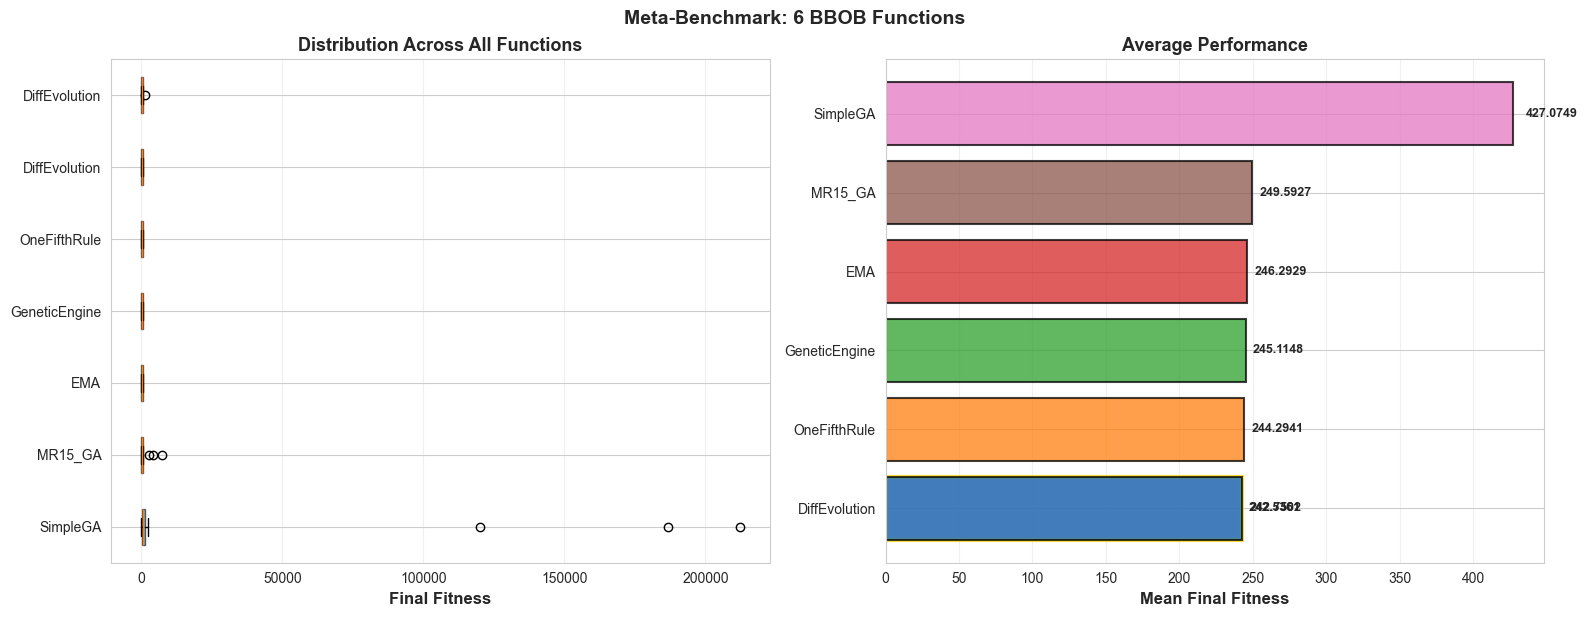

✅ Meta-benchmark visualization complete


In [ ]:
# Visualize meta-benchmark results
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Box plot
ax1 = axes[0]
data_to_plot = [meta_results[result[0]] for result in sorted_engines[::-1]]
labels = [result[0].split(' - ')[1] for result in sorted_engines[::-1]]
bp = ax1.boxplot(data_to_plot, labels=labels, vert=False, patch_artist=True)
for i, patch in enumerate(bp['boxes']):
    color = malthusjax_colors[i] if i < 4 else evosax_colors[i-4]
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax1.set_xlabel('Final Fitness', fontsize=12, fontweight='bold')
ax1.set_title('Distribution Across All Functions', fontsize=13, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# Mean performance
ax2 = axes[1]
means = [s[1]['mean'] for s in sorted_engines]
names = [s[0].split(' - ')[1] for s in sorted_engines]
colors_sorted = []
mjx_count = 0
evx_count = 0
for engine_name, _ in sorted_engines:
    if 'MalthusJAX' in engine_name:
        colors_sorted.append(malthusjax_colors[mjx_count])
        mjx_count += 1
    else:
        colors_sorted.append(evosax_colors[evx_count])
        evx_count += 1
bars = ax2.barh(names, means, color=colors_sorted, alpha=0.75, edgecolor='black', linewidth=1.5)
ax2.set_xlabel('Mean Final Fitness', fontsize=12, fontweight='bold')
ax2.set_title('Average Performance', fontsize=13, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)
for bar, val in zip(bars, means):
    ax2.text(val + abs(val)*0.02, bar.get_y() + bar.get_height()/2, f'{val:.4f}',
             ha='left', va='center', fontsize=9, fontweight='bold')
bars[0].set_edgecolor('gold')
bars[0].set_linewidth(3)

plt.tight_layout()
plt.suptitle(f'Meta-Benchmark: {len(META_FUNCTIONS)} BBOB Functions', fontsize=14, fontweight='bold', y=1.02)
plt.show()

print("✅ Meta-benchmark visualization complete")

## 11. HLO Analysis: Scan Unrolling Optimization

Analyze how different `jax.lax.scan` unroll values affect compilation and performance.

In [ ]:
# ============================================================================
# HLO Analysis Data Structures
# ============================================================================

@dataclass
class ConfigMetrics:
    """Metrics extracted from HLO for a specific unroll configuration."""
    total_instructions: int
    loop_count: int
    fusion_count: int
    fusion_size_avg: float
    memory_ops: Dict[str, int]  # {op_type: count}
    estimated_compute_ops: int
    estimated_memory_traffic: float

@dataclass
class UnrollConfiguration:
    """HLO compilation result for a specific unroll value."""
    unroll: int
    hlo_text: str
    metrics: ConfigMetrics

@dataclass
class ComparisonDelta:
    """Comparison metrics between an unroll config and baseline."""
    unroll: int
    instruction_change_pct: float
    loop_reduction: int
    fusion_improvement: int
    memory_ops_reduction: Dict[str, int]
    key_differences: List[str]

@dataclass
class PairwiseComparisons:
    """Pairwise comparisons against baseline."""
    baseline_unroll: int
    deltas: Dict[int, ComparisonDelta]

@dataclass
class TrendAnalysis:
    """Overall trends across unroll values."""
    instruction_growth_rate: str  # "linear", "quadratic", etc.
    fusion_trend: str
    diminishing_returns_at: Optional[int]  # unroll value where benefits plateau
    compilation_time_trend: str

@dataclass
class Recommendations:
    """Optimization recommendations."""
    optimal_unroll: int
    reasoning: str
    tradeoffs: Dict[int, str]  # {unroll: "pros/cons"}

@dataclass
class UnrollComparisonReport:
    """Complete analysis report for scan unrolling."""
    configurations: List[UnrollConfiguration]
    comparisons: PairwiseComparisons
    trends: TrendAnalysis
    recommendations: Recommendations
    summary: str

print("✅ HLO analysis data structures defined")

✅ HLO analysis data structures defined


In [ ]:
import re

def extract_hlo_metrics(hlo_text: str) -> ConfigMetrics:
    """Extract metrics from HLO IR text."""
    lines = hlo_text.split('\n')
    
    # Count instructions
    total_instructions = len([l for l in lines if l.strip() and not l.strip().startswith('//')])
    
    # Count loops (while operations)
    loop_count = len(re.findall(r'\bwhile\b', hlo_text))
    
    # Count fusion operations
    fusion_matches = re.findall(r'fusion\.[0-9]+', hlo_text)
    fusion_count = len(set(fusion_matches))
    
    # Estimate fusion sizes
    fusion_sizes = []
    in_fusion = False
    current_fusion_size = 0
    for line in lines:
        if 'fusion' in line and '{' in line:
            in_fusion = True
            current_fusion_size = 0
        elif in_fusion:
            if '}' in line:
                fusion_sizes.append(current_fusion_size)
                in_fusion = False
            else:
                current_fusion_size += 1
    fusion_size_avg = sum(fusion_sizes) / len(fusion_sizes) if fusion_sizes else 0.0
    
    # Count memory operations
    memory_ops = {
        'load': len(re.findall(r'\bload\b', hlo_text)),
        'store': len(re.findall(r'\bstore\b', hlo_text)),
        'copy': len(re.findall(r'\bcopy\b', hlo_text)),
    }
    
    # Estimate compute operations (arithmetic ops)
    compute_patterns = [r'\badd\b', r'\bmultiply\b', r'\bsubtract\b', r'\bdivide\b', 
                       r'\bdot\b', r'\bconvolution\b', r'\bexp\b', r'\blog\b']
    estimated_compute_ops = sum(len(re.findall(p, hlo_text)) for p in compute_patterns)
    
    # Estimate memory traffic (simplified)
    estimated_memory_traffic = float(sum(memory_ops.values()))
    
    return ConfigMetrics(
        total_instructions=total_instructions,
        loop_count=loop_count,
        fusion_count=fusion_count,
        fusion_size_avg=fusion_size_avg,
        memory_ops=memory_ops,
        estimated_compute_ops=estimated_compute_ops,
        estimated_memory_traffic=estimated_memory_traffic
    )

print("✅ HLO metrics extraction function defined")

✅ HLO metrics extraction function defined


In [ ]:
def analyze_scan_unrolling(
    step_fn: Callable,
    init_state: Any,
    xs: Any,
    unroll_values: List[int] = [1, 2, 4, 8, 16],
    length: Optional[int] = None,
    reverse: bool = False,
) -> UnrollComparisonReport:
    """
    Analyze how different scan unroll values affect HLO compilation.
    
    Args:
        step_fn: The scan step function (signature: (carry, x) -> (new_carry, y))
        init_state: Initial carry/state value
        xs: Input sequence to scan over
        unroll_values: List of unroll values to compare
        length: Optional scan length override
        reverse: Whether this is a reverse scan
    
    Returns:
        UnrollComparisonReport with complete analysis
    """
    print(f"\n🔍 Analyzing scan unrolling for {len(unroll_values)} configurations...")
    print(f"   Unroll values: {unroll_values}")
    print(f"   Scan length: {length if length else 'auto'}")
    print(f"   Reverse: {reverse}\n")
    
    configurations = []
    
    # Compile and extract HLO for each unroll value
    for unroll in unroll_values:
        print(f"  Compiling with unroll={unroll}...", end=" ")
        
        # Create scan function with this unroll value
        if length is not None:
            scan_fn = lambda carry, xs: jax.lax.scan(
                step_fn, carry, xs, length=length, reverse=reverse, unroll=unroll
            )
        else:
            scan_fn = lambda carry, xs: jax.lax.scan(
                step_fn, carry, xs, reverse=reverse, unroll=unroll
            )
        
        # JIT compile
        jitted_fn = jax.jit(scan_fn)
        
        # Get HLO
        hlo_text = jitted_fn.lower(init_state, xs).as_text()
        
        # Extract metrics
        metrics = extract_hlo_metrics(hlo_text)
        
        configurations.append(UnrollConfiguration(
            unroll=unroll,
            hlo_text=hlo_text,
            metrics=metrics
        ))
        
        print(f"✓ ({metrics.total_instructions} instructions, {metrics.fusion_count} fusions)")
    
    # Pairwise comparisons (baseline = smallest unroll)
    baseline_idx = 0
    baseline = configurations[baseline_idx]
    baseline_unroll = baseline.unroll
    
    deltas = {}
    for config in configurations[1:]:
        instr_change = ((config.metrics.total_instructions - baseline.metrics.total_instructions) 
                       / baseline.metrics.total_instructions * 100)
        loop_reduction = baseline.metrics.loop_count - config.metrics.loop_count
        fusion_improvement = config.metrics.fusion_count - baseline.metrics.fusion_count
        
        mem_ops_reduction = {
            op: baseline.metrics.memory_ops.get(op, 0) - config.metrics.memory_ops.get(op, 0)
            for op in baseline.metrics.memory_ops.keys()
        }
        
        key_diffs = []
        if abs(instr_change) > 10:
            key_diffs.append(f"Instructions {'+' if instr_change > 0 else ''}{instr_change:.1f}%")
        if loop_reduction != 0:
            key_diffs.append(f"Loops {loop_reduction:+d}")
        if fusion_improvement != 0:
            key_diffs.append(f"Fusions {fusion_improvement:+d}")
        
        deltas[config.unroll] = ComparisonDelta(
            unroll=config.unroll,
            instruction_change_pct=instr_change,
            loop_reduction=loop_reduction,
            fusion_improvement=fusion_improvement,
            memory_ops_reduction=mem_ops_reduction,
            key_differences=key_diffs
        )
    
    comparisons = PairwiseComparisons(baseline_unroll=baseline_unroll, deltas=deltas)
    
    # Trend analysis
    instruction_counts = [c.metrics.total_instructions for c in configurations]
    fusion_counts = [c.metrics.fusion_count for c in configurations]
    
    # Detect growth rate (simplified)
    instr_ratios = [instruction_counts[i+1] / instruction_counts[i] 
                   for i in range(len(instruction_counts)-1)]
    avg_ratio = sum(instr_ratios) / len(instr_ratios)
    
    if avg_ratio < 1.2:
        growth_rate = "linear"
    elif avg_ratio < 1.5:
        growth_rate = "sub-quadratic"
    else:
        growth_rate = "quadratic or worse"
    
    # Fusion trend
    if all(fusion_counts[i] <= fusion_counts[i+1] for i in range(len(fusion_counts)-1)):
        fusion_trend = "improving"
    elif all(fusion_counts[i] >= fusion_counts[i+1] for i in range(len(fusion_counts)-1)):
        fusion_trend = "degrading"
    else:
        fusion_trend = "mixed"
    
    # Diminishing returns detection
    diminishing_at = None
    for i in range(1, len(configurations)-1):
        improvement_prev = configurations[i].metrics.fusion_count - configurations[i-1].metrics.fusion_count
        improvement_next = configurations[i+1].metrics.fusion_count - configurations[i].metrics.fusion_count
        if improvement_next < improvement_prev * 0.5:
            diminishing_at = configurations[i].unroll
            break
    
    trends = TrendAnalysis(
        instruction_growth_rate=growth_rate,
        fusion_trend=fusion_trend,
        diminishing_returns_at=diminishing_at,
        compilation_time_trend="estimated proportional to instruction count"
    )
    
    # Recommendations
    # Simple heuristic: best fusion/instruction ratio
    scores = []
    for config in configurations:
        if config.metrics.total_instructions > 0:
            score = config.metrics.fusion_count / (config.metrics.total_instructions / 1000)
        else:
            score = 0
        scores.append((config.unroll, score))
    
    optimal_unroll = max(scores, key=lambda x: x[1])[0]
    
    tradeoffs = {}
    for config in configurations:
        if config.unroll == 1:
            tradeoffs[config.unroll] = "Minimal compilation overhead, maximum loop overhead"
        elif config.unroll == optimal_unroll:
            tradeoffs[config.unroll] = f"Optimal fusion ({config.metrics.fusion_count}), balanced overhead"
        elif config.unroll == max(unroll_values):
            tradeoffs[config.unroll] = "Maximum unrolling, highest compilation cost"
        else:
            tradeoffs[config.unroll] = f"Intermediate: {config.metrics.fusion_count} fusions"
    
    reasoning = (f"Unroll={optimal_unroll} provides best fusion efficiency "
                f"({configurations[[c.unroll for c in configurations].index(optimal_unroll)].metrics.fusion_count} fusions) "
                f"with {instruction_counts[[c.unroll for c in configurations].index(optimal_unroll)]} instructions. "
                f"Growth rate is {growth_rate}.")
    
    recommendations = Recommendations(
        optimal_unroll=optimal_unroll,
        reasoning=reasoning,
        tradeoffs=tradeoffs
    )
    
    # Summary
    summary = f"""
Scan Unrolling Analysis Summary
{'='*70}
Configurations tested: {len(configurations)}
Baseline (unroll={baseline_unroll}): {baseline.metrics.total_instructions} instructions, {baseline.metrics.fusion_count} fusions
Best (unroll={optimal_unroll}): {configurations[[c.unroll for c in configurations].index(optimal_unroll)].metrics.total_instructions} instructions, {configurations[[c.unroll for c in configurations].index(optimal_unroll)].metrics.fusion_count} fusions

Trends:
  - Instruction growth: {growth_rate}
  - Fusion trend: {fusion_trend}
  - Diminishing returns at: unroll={diminishing_at if diminishing_at else 'N/A'}

Recommendation: Use unroll={optimal_unroll}
{'='*70}
    """.strip()
    
    return UnrollComparisonReport(
        configurations=configurations,
        comparisons=comparisons,
        trends=trends,
        recommendations=recommendations,
        summary=summary
    )

print("✅ analyze_scan_unrolling function defined")

✅ analyze_scan_unrolling function defined


### Example: Analyze Evosax DifferentialEvolution Step Function

In [ ]:
# Setup a simple evolution step for analysis
ANALYSIS_DIMS = 10
ANALYSIS_POPSIZE = 20
ANALYSIS_GENS = 50

# Create problem and strategy
analysis_problem = BBOBProblem("sphere", num_dims=ANALYSIS_DIMS, seed=42)
analysis_de = DifferentialEvolution(population_size=ANALYSIS_POPSIZE, solution=analysis_problem.sample(jar.PRNGKey(42)))
analysis_params = analysis_de.default_params

# Initialize state
rng_init = jar.PRNGKey(100)
rng_pop = jar.PRNGKey(101)
init_pop = jax.random.uniform(rng_pop, (ANALYSIS_POPSIZE, ANALYSIS_DIMS), minval=-5.0, maxval=5.0)
init_fit = jnp.full((ANALYSIS_POPSIZE,), jnp.inf)
analysis_state = analysis_de.init(rng_init, init_pop, init_fit, analysis_params)
analysis_prob_state = analysis_problem.init(jar.PRNGKey(42))

# Define step function
def evosax_step(carry, _):
    state, prob_state, rng = carry
    rng_ask, rng_eval, rng_tell, rng_next = jax.random.split(rng, 4)
    x, state = analysis_de.ask(rng_ask, state, analysis_params)
    x = jnp.clip(x, -5.0, 5.0)
    fitness, prob_state, _ = analysis_problem.eval(rng_eval, x, prob_state)
    state, metrics = analysis_de.tell(rng_tell, x, fitness, state, analysis_params)
    return (state, prob_state, rng_next), fitness.min()    

# Initial carry
analysis_carry = (analysis_state, analysis_prob_state, jar.PRNGKey(102))

print(f"✅ Analysis setup complete:")
print(f"   Problem: sphere ({ANALYSIS_DIMS}D)")
print(f"   Population: {ANALYSIS_POPSIZE}")
print(f"   Generations: {ANALYSIS_GENS}")

✅ Analysis setup complete:
   Problem: sphere (10D)
   Population: 20
   Generations: 50


In [ ]:
# Run the analysis
report = analyze_scan_unrolling(
    step_fn=evosax_step,
    init_state=analysis_carry,
    xs=None,
    unroll_values=[1, 2, 4, 8, 16],
    length=ANALYSIS_GENS,
    reverse=False
)

# Display summary
print("\n" + report.summary)


🔍 Analyzing scan unrolling for 5 configurations...
   Unroll values: [1, 2, 4, 8, 16]
   Scan length: 50
   Reverse: False

  Compiling with unroll=1... ✓ (1327 instructions, 0 fusions)
  Compiling with unroll=2... ✓ (1333 instructions, 0 fusions)
  Compiling with unroll=4... ✓ (1343 instructions, 0 fusions)
  Compiling with unroll=8... ✓ (1351 instructions, 0 fusions)
  Compiling with unroll=16... ✓ (1367 instructions, 0 fusions)

Scan Unrolling Analysis Summary
Configurations tested: 5
Baseline (unroll=1): 1327 instructions, 0 fusions
Best (unroll=1): 1327 instructions, 0 fusions

Trends:
  - Instruction growth: linear
  - Fusion trend: improving
  - Diminishing returns at: unroll=N/A

Recommendation: Use unroll=1


### Detailed Analysis Results

In [ ]:
# Display configuration metrics
print("\n" + "="*90)
print("CONFIGURATION METRICS")
print("="*90)
print(f"{'Unroll':>8} {'Instructions':>15} {'Loops':>8} {'Fusions':>10} {'Fusion Avg':>12} {'Compute Ops':>12}")
print("-"*90)

for config in report.configurations:
    m = config.metrics
    print(f"{config.unroll:>8} {m.total_instructions:>15,} {m.loop_count:>8} {m.fusion_count:>10} "
          f"{m.fusion_size_avg:>12.1f} {m.estimated_compute_ops:>12,}")

print("="*90)

# Display comparisons
print("\n" + "="*90)
print(f"PAIRWISE COMPARISONS (vs baseline unroll={report.comparisons.baseline_unroll})")
print("="*90)
print(f"{'Unroll':>8} {'Instr Change':>15} {'Loop Δ':>10} {'Fusion Δ':>12} {'Key Differences':<30}")
print("-"*90)

for unroll, delta in sorted(report.comparisons.deltas.items()):
    key_diffs_str = "; ".join(delta.key_differences[:2]) if delta.key_differences else "minimal"
    print(f"{delta.unroll:>8} {delta.instruction_change_pct:>14.1f}% {delta.loop_reduction:>10} "
          f"{delta.fusion_improvement:>12} {key_diffs_str:<30}")

print("="*90)

# Display trends
print("\n" + "="*70)
print("TREND ANALYSIS")
print("="*70)
print(f"Instruction Growth:      {report.trends.instruction_growth_rate}")
print(f"Fusion Trend:            {report.trends.fusion_trend}")
print(f"Diminishing Returns At:  unroll={report.trends.diminishing_returns_at if report.trends.diminishing_returns_at else 'N/A'}")
print(f"Compilation Time:        {report.trends.compilation_time_trend}")
print("="*70)

# Display recommendations
print("\n" + "="*70)
print("RECOMMENDATIONS")
print("="*70)
print(f"Optimal Unroll: {report.recommendations.optimal_unroll}")
print(f"\nReasoning:")
print(f"  {report.recommendations.reasoning}")
print(f"\nTradeoffs:")
for unroll, tradeoff in sorted(report.recommendations.tradeoffs.items()):
    print(f"  unroll={unroll}: {tradeoff}")
print("="*70)


CONFIGURATION METRICS
  Unroll    Instructions    Loops    Fusions   Fusion Avg  Compute Ops
------------------------------------------------------------------------------------------
       1           1,327        9          0          0.0          167
       2           1,333        9          0          0.0          167
       4           1,343        9          0          0.0          167
       8           1,351        9          0          0.0          167
      16           1,367        9          0          0.0          167

PAIRWISE COMPARISONS (vs baseline unroll=1)
  Unroll    Instr Change     Loop Δ     Fusion Δ Key Differences               
------------------------------------------------------------------------------------------
       2            0.5%          0            0 minimal                       
       4            1.2%          0            0 minimal                       
       8            1.8%          0            0 minimal                       
    

### Visualization: Unroll Impact

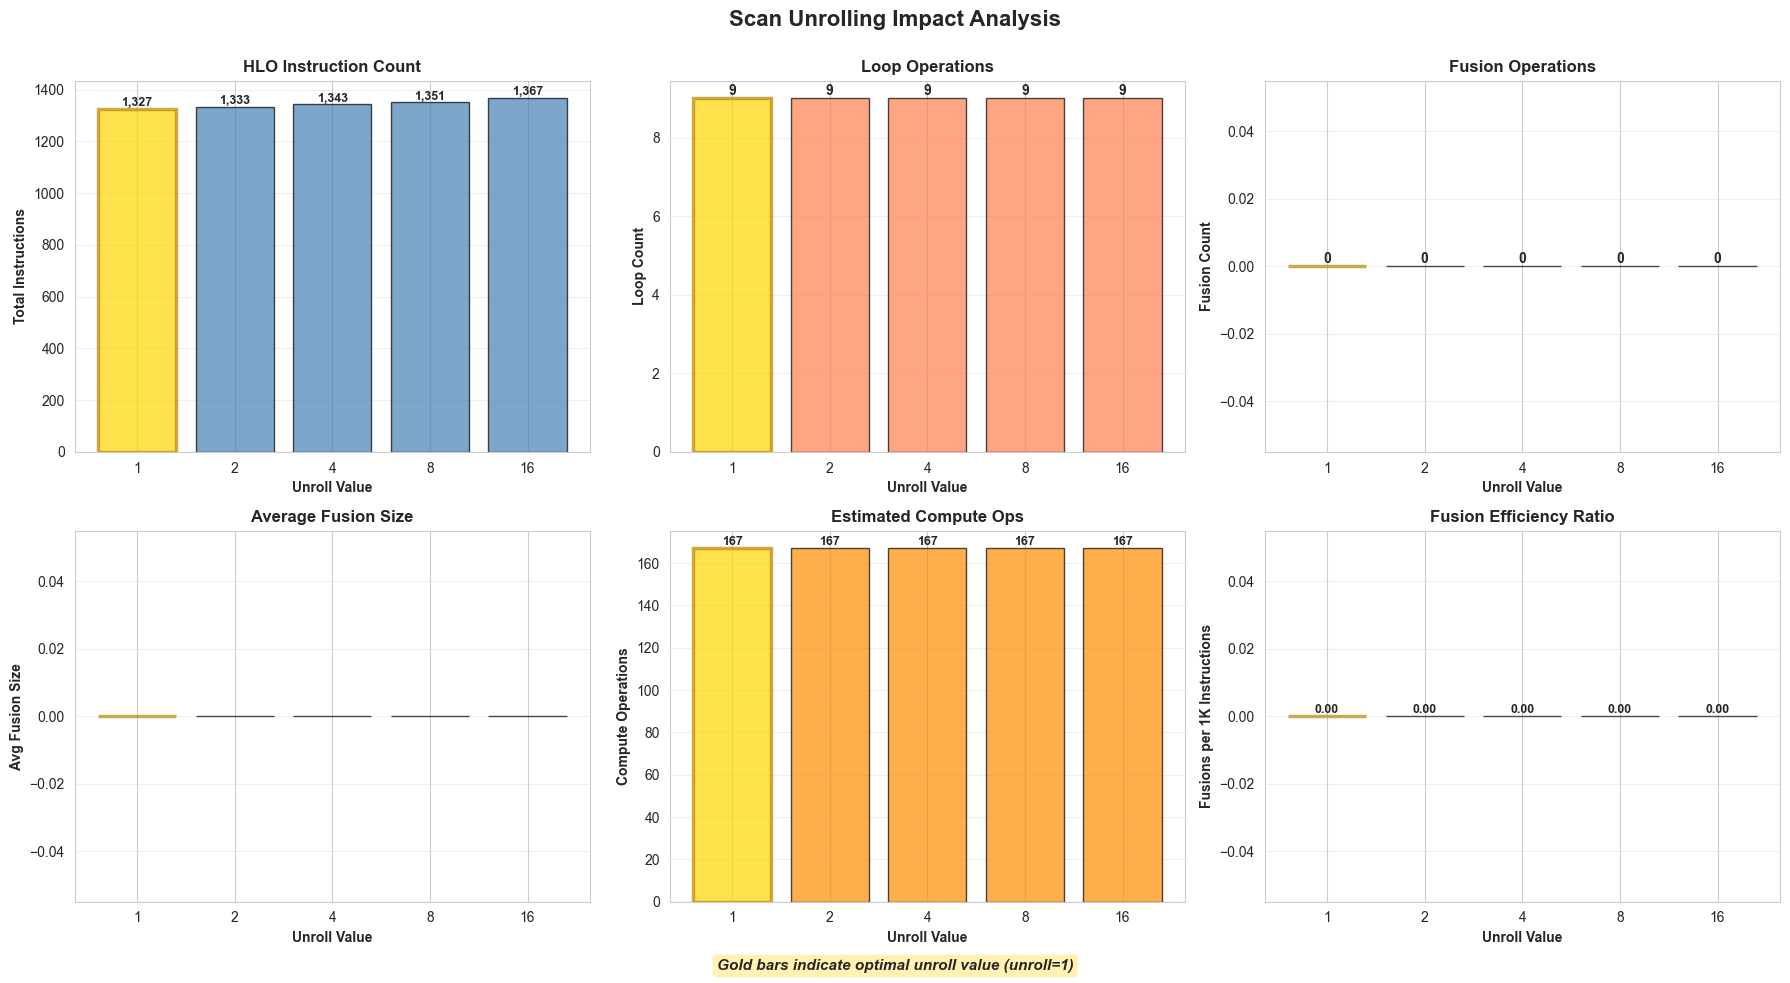


✅ Unrolling analysis visualization complete
   Optimal unroll: 1
   Instruction growth: linear
   Fusion trend: improving


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Scan Unrolling Impact Analysis', fontsize=16, fontweight='bold')

unrolls = [c.unroll for c in report.configurations]
instructions = [c.metrics.total_instructions for c in report.configurations]
loops = [c.metrics.loop_count for c in report.configurations]
fusions = [c.metrics.fusion_count for c in report.configurations]
fusion_avgs = [c.metrics.fusion_size_avg for c in report.configurations]
compute_ops = [c.metrics.estimated_compute_ops for c in report.configurations]
memory_traffic = [c.metrics.estimated_memory_traffic for c in report.configurations]

optimal_idx = unrolls.index(report.recommendations.optimal_unroll)

# Plot 1: Total Instructions
ax1 = axes[0, 0]
bars = ax1.bar(range(len(unrolls)), instructions, color='steelblue', alpha=0.7, edgecolor='black')
bars[optimal_idx].set_color('gold')
bars[optimal_idx].set_edgecolor('darkgoldenrod')
bars[optimal_idx].set_linewidth(2.5)
ax1.set_xticks(range(len(unrolls)))
ax1.set_xticklabels([f'{u}' for u in unrolls])
ax1.set_xlabel('Unroll Value', fontweight='bold')
ax1.set_ylabel('Total Instructions', fontweight='bold')
ax1.set_title('HLO Instruction Count', fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
for i, (bar, val) in enumerate(zip(bars, instructions)):
    ax1.text(bar.get_x() + bar.get_width()/2, val, f'{val:,}',
             ha='center', va='bottom', fontsize=9, fontweight='bold')

# Plot 2: Loop Count
ax2 = axes[0, 1]
bars = ax2.bar(range(len(unrolls)), loops, color='coral', alpha=0.7, edgecolor='black')
bars[optimal_idx].set_color('gold')
bars[optimal_idx].set_edgecolor('darkgoldenrod')
bars[optimal_idx].set_linewidth(2.5)
ax2.set_xticks(range(len(unrolls)))
ax2.set_xticklabels([f'{u}' for u in unrolls])
ax2.set_xlabel('Unroll Value', fontweight='bold')
ax2.set_ylabel('Loop Count', fontweight='bold')
ax2.set_title('Loop Operations', fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
for i, (bar, val) in enumerate(zip(bars, loops)):
    if val > 0:
        ax2.text(bar.get_x() + bar.get_width()/2, val, f'{val}',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

# Plot 3: Fusion Count
ax3 = axes[0, 2]
bars = ax3.bar(range(len(unrolls)), fusions, color='mediumseagreen', alpha=0.7, edgecolor='black')
bars[optimal_idx].set_color('gold')
bars[optimal_idx].set_edgecolor('darkgoldenrod')
bars[optimal_idx].set_linewidth(2.5)
ax3.set_xticks(range(len(unrolls)))
ax3.set_xticklabels([f'{u}' for u in unrolls])
ax3.set_xlabel('Unroll Value', fontweight='bold')
ax3.set_ylabel('Fusion Count', fontweight='bold')
ax3.set_title('Fusion Operations', fontweight='bold')
ax3.grid(axis='y', alpha=0.3)
for i, (bar, val) in enumerate(zip(bars, fusions)):
    ax3.text(bar.get_x() + bar.get_width()/2, val, f'{val}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# Plot 4: Fusion Size Average
ax4 = axes[1, 0]
bars = ax4.bar(range(len(unrolls)), fusion_avgs, color='mediumpurple', alpha=0.7, edgecolor='black')
bars[optimal_idx].set_color('gold')
bars[optimal_idx].set_edgecolor('darkgoldenrod')
bars[optimal_idx].set_linewidth(2.5)
ax4.set_xticks(range(len(unrolls)))
ax4.set_xticklabels([f'{u}' for u in unrolls])
ax4.set_xlabel('Unroll Value', fontweight='bold')
ax4.set_ylabel('Avg Fusion Size', fontweight='bold')
ax4.set_title('Average Fusion Size', fontweight='bold')
ax4.grid(axis='y', alpha=0.3)
for i, (bar, val) in enumerate(zip(bars, fusion_avgs)):
    if val > 0:
        ax4.text(bar.get_x() + bar.get_width()/2, val, f'{val:.1f}',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')

# Plot 5: Compute Operations
ax5 = axes[1, 1]
bars = ax5.bar(range(len(unrolls)), compute_ops, color='darkorange', alpha=0.7, edgecolor='black')
bars[optimal_idx].set_color('gold')
bars[optimal_idx].set_edgecolor('darkgoldenrod')
bars[optimal_idx].set_linewidth(2.5)
ax5.set_xticks(range(len(unrolls)))
ax5.set_xticklabels([f'{u}' for u in unrolls])
ax5.set_xlabel('Unroll Value', fontweight='bold')
ax5.set_ylabel('Compute Operations', fontweight='bold')
ax5.set_title('Estimated Compute Ops', fontweight='bold')
ax5.grid(axis='y', alpha=0.3)
for i, (bar, val) in enumerate(zip(bars, compute_ops)):
    ax5.text(bar.get_x() + bar.get_width()/2, val, f'{val:,}',
             ha='center', va='bottom', fontsize=9, fontweight='bold')

# Plot 6: Efficiency Ratio (Fusions per 1K instructions)
ax6 = axes[1, 2]
efficiency = [f / (i / 1000) if i > 0 else 0 for f, i in zip(fusions, instructions)]
bars = ax6.bar(range(len(unrolls)), efficiency, color='teal', alpha=0.7, edgecolor='black')
bars[optimal_idx].set_color('gold')
bars[optimal_idx].set_edgecolor('darkgoldenrod')
bars[optimal_idx].set_linewidth(2.5)
ax6.set_xticks(range(len(unrolls)))
ax6.set_xticklabels([f'{u}' for u in unrolls])
ax6.set_xlabel('Unroll Value', fontweight='bold')
ax6.set_ylabel('Fusions per 1K Instructions', fontweight='bold')
ax6.set_title('Fusion Efficiency Ratio', fontweight='bold')
ax6.grid(axis='y', alpha=0.3)
for i, (bar, val) in enumerate(zip(bars, efficiency)):
    ax6.text(bar.get_x() + bar.get_width()/2, val, f'{val:.2f}',
             ha='center', va='bottom', fontsize=9, fontweight='bold')

# Add legend explaining optimal marker
fig.text(0.5, 0.02, f'Gold bars indicate optimal unroll value (unroll={report.recommendations.optimal_unroll})',
         ha='center', fontsize=11, fontweight='bold', style='italic',
         bbox=dict(boxstyle='round', facecolor='gold', alpha=0.3))

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

print(f"\n✅ Unrolling analysis visualization complete")
print(f"   Optimal unroll: {report.recommendations.optimal_unroll}")
print(f"   Instruction growth: {report.trends.instruction_growth_rate}")
print(f"   Fusion trend: {report.trends.fusion_trend}")

### MalthusJAX Engine Analysis

In [ ]:
# Setup MalthusJAX engines for analysis
mjx_genome_config = RealGenomeConfig(length=ANALYSIS_DIMS, bounds=(-5.0, 5.0))

mjx_bbob_config = BBOBConfig(
    fn_name="sphere",
    num_dims=ANALYSIS_DIMS,
    seed=42,
    maximize=True
)
mjx_bbob_evaluator = BBOBEvaluator.create(mjx_bbob_config)

elite_size_analysis = int(ANALYSIS_POPSIZE * 0.2)

# Create engines for analysis
mjx_engines_for_analysis = {
    "GeneticEngine": GeneticEngine(
        evaluator=mjx_bbob_evaluator,
        selection=ElitePoolSelection(num_selections=ANALYSIS_POPSIZE, elite_k=elite_size_analysis, input_length=ANALYSIS_POPSIZE),
        crossover=UniformCrossover(num_offspring=2, crossover_rate=0.9),
        mutation=GaussianMutation(num_offspring=1, mutation_rate=0.3, mutation_strength=0.1),
        genome_config=mjx_genome_config,
        engine_params=GeneticEngineParams(pop_size=ANALYSIS_POPSIZE, num_generations=ANALYSIS_GENS, elitism=0)
    ),
    "DiffEvolution": DifferentialEvolutionEngine(
        genome_config=mjx_genome_config,
        evaluator=mjx_bbob_evaluator,
        mutation=DitherMutation(low=0.2, high=0.8, clip=True),
        crossover=BinomialCrossover(crossover_rate=0.9),
        engine_params=AbstractEngineParams(pop_size=ANALYSIS_POPSIZE, num_generations=ANALYSIS_GENS, elitism=0),
        enable_progress_bar=False
    )
}

print(f"✅ MalthusJAX engines setup for analysis:")
for name in mjx_engines_for_analysis.keys():
    print(f"   - {name}")

✅ MalthusJAX engines setup for analysis:
   - GeneticEngine
   - DiffEvolution


In [ ]:
# Analyze each MalthusJAX engine
mjx_reports = {}

for engine_name, engine in mjx_engines_for_analysis.items():
    print(f"\n{'='*70}")
    print(f"Analyzing: MalthusJAX {engine_name}")
    print(f"{'='*70}")
    
    # Initialize engine state
    init_key = jar.PRNGKey(42)
    init_state = engine.init_state(init_key)
    
    # Create step function for this engine
    def mjx_step(state, _):
        new_state, _ = engine.step(state)
        return new_state, new_state.best_fitness
    
    # Run analysis
    mjx_report = analyze_scan_unrolling(
        step_fn=mjx_step,
        init_state=init_state,
        xs=None,
        unroll_values=[1, 2, 4, 8, 16],
        length=ANALYSIS_GENS,
        reverse=False
    )
    
    mjx_reports[engine_name] = mjx_report
    print("\n" + mjx_report.summary)

print(f"\n✅ Analyzed {len(mjx_reports)} MalthusJAX engines")


Analyzing: MalthusJAX GeneticEngine

🔍 Analyzing scan unrolling for 5 configurations...
   Unroll values: [1, 2, 4, 8, 16]
   Scan length: 50
   Reverse: False

  Compiling with unroll=1... ✓ (958 instructions, 0 fusions)
  Compiling with unroll=2... ✓ (964 instructions, 0 fusions)
  Compiling with unroll=4... ✓ (974 instructions, 0 fusions)
  Compiling with unroll=8... ✓ (982 instructions, 0 fusions)
  Compiling with unroll=16... ✓ (998 instructions, 0 fusions)

Scan Unrolling Analysis Summary
Configurations tested: 5
Baseline (unroll=1): 958 instructions, 0 fusions
Best (unroll=1): 958 instructions, 0 fusions

Trends:
  - Instruction growth: linear
  - Fusion trend: improving
  - Diminishing returns at: unroll=N/A

Recommendation: Use unroll=1

Analyzing: MalthusJAX DiffEvolution

🔍 Analyzing scan unrolling for 5 configurations...
   Unroll values: [1, 2, 4, 8, 16]
   Scan length: 50
   Reverse: False

  Compiling with unroll=1... ✓ (879 instructions, 0 fusions)
  Compiling with unr

### MalthusJAX Detailed Results

In [ ]:
# Display detailed results for each MalthusJAX engine
for engine_name, mjx_report in mjx_reports.items():
    print(f"\n{'='*90}")
    print(f"ENGINE: MalthusJAX {engine_name}")
    print(f"{'='*90}")
    
    # Configuration metrics
    print(f"\n{'Configuration Metrics'}")
    print("-"*90)
    print(f"{'Unroll':>8} {'Instructions':>15} {'Loops':>8} {'Fusions':>10} {'Fusion Avg':>12} {'Compute Ops':>12}")
    print("-"*90)
    
    for config in mjx_report.configurations:
        m = config.metrics
        print(f"{config.unroll:>8} {m.total_instructions:>15,} {m.loop_count:>8} {m.fusion_count:>10} "
              f"{m.fusion_size_avg:>12.1f} {m.estimated_compute_ops:>12,}")
    
    # Comparisons
    print(f"\n{'Pairwise Comparisons'}")
    print("-"*90)
    print(f"{'Unroll':>8} {'Instr Change':>15} {'Loop Δ':>10} {'Fusion Δ':>12}")
    print("-"*90)
    
    for unroll, delta in sorted(mjx_report.comparisons.deltas.items()):
        print(f"{delta.unroll:>8} {delta.instruction_change_pct:>14.1f}% {delta.loop_reduction:>10} "
              f"{delta.fusion_improvement:>12}")
    
    # Recommendations
    print(f"\n{'Recommendation'}")
    print("-"*90)
    print(f"Optimal Unroll: {mjx_report.recommendations.optimal_unroll}")
    print(f"Reasoning: {mjx_report.recommendations.reasoning}")
    print("="*90)


ENGINE: MalthusJAX GeneticEngine

Configuration Metrics
------------------------------------------------------------------------------------------
  Unroll    Instructions    Loops    Fusions   Fusion Avg  Compute Ops
------------------------------------------------------------------------------------------
       1             958        6          0          0.0          123
       2             964        6          0          0.0          123
       4             974        6          0          0.0          123
       8             982        6          0          0.0          123
      16             998        6          0          0.0          123

Pairwise Comparisons
------------------------------------------------------------------------------------------
  Unroll    Instr Change     Loop Δ     Fusion Δ
------------------------------------------------------------------------------------------
       2            0.6%          0            0
       4            1.7%         

### MalthusJAX Visualization: Per-Engine Analysis

In [ ]:
# Visualize each MalthusJAX engine separately
for engine_name, mjx_report in mjx_reports.items():
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f'MalthusJAX {engine_name} - Scan Unrolling Analysis', fontsize=16, fontweight='bold')
    
    unrolls = [c.unroll for c in mjx_report.configurations]
    instructions = [c.metrics.total_instructions for c in mjx_report.configurations]
    loops = [c.metrics.loop_count for c in mjx_report.configurations]
    fusions = [c.metrics.fusion_count for c in mjx_report.configurations]
    fusion_avgs = [c.metrics.fusion_size_avg for c in mjx_report.configurations]
    compute_ops = [c.metrics.estimated_compute_ops for c in mjx_report.configurations]
    
    optimal_idx = unrolls.index(mjx_report.recommendations.optimal_unroll)
    
    # Plot 1: Total Instructions
    ax1 = axes[0, 0]
    bars = ax1.bar(range(len(unrolls)), instructions, color='steelblue', alpha=0.7, edgecolor='black')
    bars[optimal_idx].set_color('gold')
    bars[optimal_idx].set_edgecolor('darkgoldenrod')
    bars[optimal_idx].set_linewidth(2.5)
    ax1.set_xticks(range(len(unrolls)))
    ax1.set_xticklabels([f'{u}' for u in unrolls])
    ax1.set_xlabel('Unroll Value', fontweight='bold')
    ax1.set_ylabel('Total Instructions', fontweight='bold')
    ax1.set_title('HLO Instruction Count', fontweight='bold')
    ax1.grid(axis='y', alpha=0.3)
    for i, (bar, val) in enumerate(zip(bars, instructions)):
        ax1.text(bar.get_x() + bar.get_width()/2, val, f'{val:,}',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # Plot 2: Loop Count
    ax2 = axes[0, 1]
    bars = ax2.bar(range(len(unrolls)), loops, color='coral', alpha=0.7, edgecolor='black')
    bars[optimal_idx].set_color('gold')
    bars[optimal_idx].set_edgecolor('darkgoldenrod')
    bars[optimal_idx].set_linewidth(2.5)
    ax2.set_xticks(range(len(unrolls)))
    ax2.set_xticklabels([f'{u}' for u in unrolls])
    ax2.set_xlabel('Unroll Value', fontweight='bold')
    ax2.set_ylabel('Loop Count', fontweight='bold')
    ax2.set_title('Loop Operations', fontweight='bold')
    ax2.grid(axis='y', alpha=0.3)
    for i, (bar, val) in enumerate(zip(bars, loops)):
        if val > 0:
            ax2.text(bar.get_x() + bar.get_width()/2, val, f'{val}',
                     ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # Plot 3: Fusion Count
    ax3 = axes[0, 2]
    bars = ax3.bar(range(len(unrolls)), fusions, color='mediumseagreen', alpha=0.7, edgecolor='black')
    bars[optimal_idx].set_color('gold')
    bars[optimal_idx].set_edgecolor('darkgoldenrod')
    bars[optimal_idx].set_linewidth(2.5)
    ax3.set_xticks(range(len(unrolls)))
    ax3.set_xticklabels([f'{u}' for u in unrolls])
    ax3.set_xlabel('Unroll Value', fontweight='bold')
    ax3.set_ylabel('Fusion Count', fontweight='bold')
    ax3.set_title('Fusion Operations', fontweight='bold')
    ax3.grid(axis='y', alpha=0.3)
    for i, (bar, val) in enumerate(zip(bars, fusions)):
        ax3.text(bar.get_x() + bar.get_width()/2, val, f'{val}',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # Plot 4: Fusion Size Average
    ax4 = axes[1, 0]
    bars = ax4.bar(range(len(unrolls)), fusion_avgs, color='mediumpurple', alpha=0.7, edgecolor='black')
    bars[optimal_idx].set_color('gold')
    bars[optimal_idx].set_edgecolor('darkgoldenrod')
    bars[optimal_idx].set_linewidth(2.5)
    ax4.set_xticks(range(len(unrolls)))
    ax4.set_xticklabels([f'{u}' for u in unrolls])
    ax4.set_xlabel('Unroll Value', fontweight='bold')
    ax4.set_ylabel('Avg Fusion Size', fontweight='bold')
    ax4.set_title('Average Fusion Size', fontweight='bold')
    ax4.grid(axis='y', alpha=0.3)
    for i, (bar, val) in enumerate(zip(bars, fusion_avgs)):
        if val > 0:
            ax4.text(bar.get_x() + bar.get_width()/2, val, f'{val:.1f}',
                     ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # Plot 5: Instruction Change %
    ax5 = axes[1, 1]
    baseline_instr = instructions[0]
    instr_change_pct = [(i - baseline_instr) / baseline_instr * 100 for i in instructions]
    colors_change = ['green' if c <= 0 else 'red' for c in instr_change_pct]
    colors_change[optimal_idx] = 'gold'
    bars = ax5.bar(range(len(unrolls)), instr_change_pct, color=colors_change, alpha=0.7, edgecolor='black')
    bars[optimal_idx].set_edgecolor('darkgoldenrod')
    bars[optimal_idx].set_linewidth(2.5)
    ax5.set_xticks(range(len(unrolls)))
    ax5.set_xticklabels([f'{u}' for u in unrolls])
    ax5.set_xlabel('Unroll Value', fontweight='bold')
    ax5.set_ylabel('Instruction Change (%)', fontweight='bold')
    ax5.set_title('Instruction Growth vs Baseline', fontweight='bold')
    ax5.axhline(y=0, color='black', linestyle='--', linewidth=1)
    ax5.grid(axis='y', alpha=0.3)
    for i, (bar, val) in enumerate(zip(bars, instr_change_pct)):
        ax5.text(bar.get_x() + bar.get_width()/2, val, f'{val:+.1f}%',
                 ha='center', va='bottom' if val > 0 else 'top', fontsize=9, fontweight='bold')
    
    # Plot 6: Efficiency Ratio
    ax6 = axes[1, 2]
    efficiency = [f / (i / 1000) if i > 0 else 0 for f, i in zip(fusions, instructions)]
    bars = ax6.bar(range(len(unrolls)), efficiency, color='teal', alpha=0.7, edgecolor='black')
    bars[optimal_idx].set_color('gold')
    bars[optimal_idx].set_edgecolor('darkgoldenrod')
    bars[optimal_idx].set_linewidth(2.5)
    ax6.set_xticks(range(len(unrolls)))
    ax6.set_xticklabels([f'{u}' for u in unrolls])
    ax6.set_xlabel('Unroll Value', fontweight='bold')
    ax6.set_ylabel('Fusions per 1K Instructions', fontweight='bold')
    ax6.set_title('Fusion Efficiency Ratio', fontweight='bold')
    ax6.grid(axis='y', alpha=0.3)
    for i, (bar, val) in enumerate(zip(bars, efficiency)):
        ax6.text(bar.get_x() + bar.get_width()/2, val, f'{val:.2f}',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # Add legend
    fig.text(0.5, 0.02, 
             f'Optimal: unroll={mjx_report.recommendations.optimal_unroll} | '
             f'Growth: {mjx_report.trends.instruction_growth_rate} | '
             f'Fusion: {mjx_report.trends.fusion_trend}',
             ha='center', fontsize=11, fontweight='bold', style='italic',
             bbox=dict(boxstyle='round', facecolor='gold', alpha=0.3))
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.98])
    plt.show()
    
    print(f"✅ {engine_name} visualization complete")

print(f"\n✅ All MalthusJAX engine visualizations complete")

### Comparative Summary: MalthusJAX vs Evosax

In [ ]:
# Create comparative summary table
print("\n" + "="*120)
print("COMPARATIVE SUMMARY: SCAN UNROLLING ANALYSIS")
print("="*120)
print(f"{'Framework':<15} {'Engine':<20} {'Optimal':>10} {'Baseline':>12} {'Best Instr':>15} {'Best Fusions':>15} {'Growth Rate':<20}")
print("-"*120)

# Evosax
evosax_name = "Evosax"
evosax_engine = "DiffEvolution"
baseline_config = report.configurations[0]
optimal_config = [c for c in report.configurations if c.unroll == report.recommendations.optimal_unroll][0]
print(f"{evosax_name:<15} {evosax_engine:<20} {report.recommendations.optimal_unroll:>10} "
      f"{baseline_config.metrics.total_instructions:>12,} {optimal_config.metrics.total_instructions:>15,} "
      f"{optimal_config.metrics.fusion_count:>15} {report.trends.instruction_growth_rate:<20}")

# MalthusJAX engines
for engine_name, mjx_report in mjx_reports.items():
    baseline_config = mjx_report.configurations[0]
    optimal_config = [c for c in mjx_report.configurations if c.unroll == mjx_report.recommendations.optimal_unroll][0]
    print(f"{'MalthusJAX':<15} {engine_name:<20} {mjx_report.recommendations.optimal_unroll:>10} "
          f"{baseline_config.metrics.total_instructions:>12,} {optimal_config.metrics.total_instructions:>15,} "
          f"{optimal_config.metrics.fusion_count:>15} {mjx_report.trends.instruction_growth_rate:<20}")

print("="*120)

# Key insights
print("\n" + "="*120)
print("KEY INSIGHTS")
print("="*120)

all_reports = {"Evosax-DiffEvolution": report}
all_reports.update({f"MalthusJAX-{k}": v for k, v in mjx_reports.items()})

print("\nOptimal Unroll Values:")
for name, rpt in all_reports.items():
    print(f"  {name:<30}: unroll={rpt.recommendations.optimal_unroll}")

print("\nInstruction Growth Patterns:")
for name, rpt in all_reports.items():
    print(f"  {name:<30}: {rpt.trends.instruction_growth_rate}")

print("\nFusion Trends:")
for name, rpt in all_reports.items():
    print(f"  {name:<30}: {rpt.trends.fusion_trend}")

print("\nDiminishing Returns:")
for name, rpt in all_reports.items():
    dim_ret = rpt.trends.diminishing_returns_at if rpt.trends.diminishing_returns_at else "N/A"
    print(f"  {name:<30}: unroll={dim_ret}")

print("="*120)

### Comparative Visualization: All Engines

In [ ]:
# Create side-by-side comparison of all engines
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Framework Comparison: Scan Unrolling Impact', fontsize=16, fontweight='bold')

all_reports_dict = {"Evosax-DE": report}
all_reports_dict.update({f"MJX-{k}": v for k, v in mjx_reports.items()})

unroll_values = [1, 2, 4, 8, 16]
colors_framework = {'Evosax-DE': '#9467bd', 'MJX-GeneticEngine': '#1f77b4', 'MJX-DiffEvolution': '#d62728'}

# Plot 1: Instructions vs Unroll
ax1 = axes[0, 0]
for name, rpt in all_reports_dict.items():
    instructions = [c.metrics.total_instructions for c in rpt.configurations]
    ax1.plot(unroll_values, instructions, marker='o', linewidth=2.5, 
             label=name, color=colors_framework.get(name, 'gray'), markersize=8)
ax1.set_xlabel('Unroll Value', fontweight='bold', fontsize=11)
ax1.set_ylabel('Total Instructions', fontweight='bold', fontsize=11)
ax1.set_title('Instruction Count Growth', fontweight='bold', fontsize=12)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xticks(unroll_values)

# Plot 2: Fusions vs Unroll
ax2 = axes[0, 1]
for name, rpt in all_reports_dict.items():
    fusions = [c.metrics.fusion_count for c in rpt.configurations]
    ax2.plot(unroll_values, fusions, marker='s', linewidth=2.5,
             label=name, color=colors_framework.get(name, 'gray'), markersize=8)
ax2.set_xlabel('Unroll Value', fontweight='bold', fontsize=11)
ax2.set_ylabel('Fusion Count', fontweight='bold', fontsize=11)
ax2.set_title('Fusion Operations', fontweight='bold', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_xticks(unroll_values)

# Plot 3: Efficiency Ratio
ax3 = axes[1, 0]
for name, rpt in all_reports_dict.items():
    instructions = [c.metrics.total_instructions for c in rpt.configurations]
    fusions = [c.metrics.fusion_count for c in rpt.configurations]
    efficiency = [f / (i / 1000) if i > 0 else 0 for f, i in zip(fusions, instructions)]
    ax3.plot(unroll_values, efficiency, marker='^', linewidth=2.5,
             label=name, color=colors_framework.get(name, 'gray'), markersize=8)
ax3.set_xlabel('Unroll Value', fontweight='bold', fontsize=11)
ax3.set_ylabel('Fusions per 1K Instructions', fontweight='bold', fontsize=11)
ax3.set_title('Fusion Efficiency', fontweight='bold', fontsize=12)
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)
ax3.set_xticks(unroll_values)

# Plot 4: Optimal Unroll Comparison
ax4 = axes[1, 1]
engine_names = list(all_reports_dict.keys())
short_names = [n.replace('MJX-', 'M-') for n in engine_names]
optimal_unrolls = [rpt.recommendations.optimal_unroll for rpt in all_reports_dict.values()]
colors_bars = [colors_framework.get(name, 'gray') for name in engine_names]

bars = ax4.barh(short_names, optimal_unrolls, color=colors_bars, alpha=0.75, edgecolor='black', linewidth=1.5)
ax4.set_xlabel('Optimal Unroll Value', fontweight='bold', fontsize=11)
ax4.set_title('Recommended Unroll Settings', fontweight='bold', fontsize=12)
ax4.grid(axis='x', alpha=0.3)
ax4.set_xlim(0, max(optimal_unrolls) + 2)

for bar, val in zip(bars, optimal_unrolls):
    ax4.text(val + 0.2, bar.get_y() + bar.get_height()/2, f'{val}',
             ha='left', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✅ Comparative visualization complete")
print(f"   Analyzed {len(all_reports_dict)} engines total")
print(f"   - Evosax: 1 engine")
print(f"   - MalthusJAX: {len(mjx_reports)} engines")